# Movie Recommendation System - Part 1: Exploratory Data Analysis & Data Prep

This notebook focuses on loading the MovieLens dataset, exploring general patterns in movies, ratings, genres, and downsampling the large dataset (~20M ratings) to a high-quality, manageable subset for subsequent content-based, collaborative, and hybrid filtering models.


### Step 1: Import Required Libraries
We will import `numpy`, `pandas`, `matplotlib`, and `seaborn` for our data analysis and visualization tasks.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


### Step 2: Load the Datasets
We load `movie.csv` and `rating.csv` files. Since `rating.csv` is around 690 MB, we load it directly. We will check their shapes and column names.


In [2]:
movies = pd.read_csv('movie.csv')
ratings = pd.read_csv('rating.csv')
print(f'Movies dataset shape: {movies.shape}')
print(f'Ratings dataset shape: {ratings.shape}')
print('\nMovies columns:', list(movies.columns))
print('Ratings columns:', list(ratings.columns))


Movies dataset shape: (27278, 3)
Ratings dataset shape: (20000263, 4)

Movies columns: ['movieId', 'title', 'genres']
Ratings columns: ['userId', 'movieId', 'rating', 'timestamp']


### Step 3: Analyze Movie Genres
Movies can belong to multiple genres separated by the `|` character. We split and explode this column to analyze the count of movies per genre and plot their distribution.


Genre counts in dataset:
genres
Drama                 13344
Comedy                 8374
Thriller               4178
Romance                4127
Action                 3520
Crime                  2939
Horror                 2611
Documentary            2471
Adventure              2329
Sci-Fi                 1743
Mystery                1514
Fantasy                1412
War                    1194
Children               1139
Musical                1036
Animation              1027
Western                 676
Film-Noir               330
(no genres listed)      246
IMAX                    196
Name: count, dtype: int64


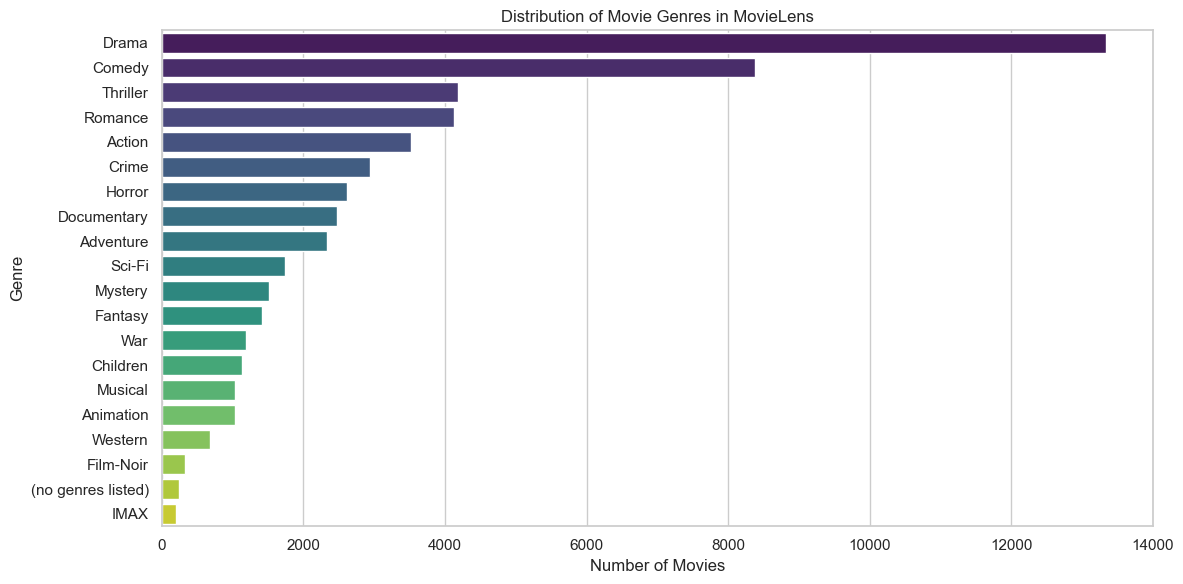

In [3]:
genres_series = movies['genres'].str.split('|').explode()
genre_counts = genres_series.value_counts()
print('Genre counts in dataset:')
print(genre_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Distribution of Movie Genres in MovieLens')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('genres_distribution.png', dpi=150)
plt.show()


### Step 4: Analyze Ratings Distribution
We plot the frequency count of each rating value (0.5 to 5.0) to understand user rating preferences and compute the mean and median ratings.


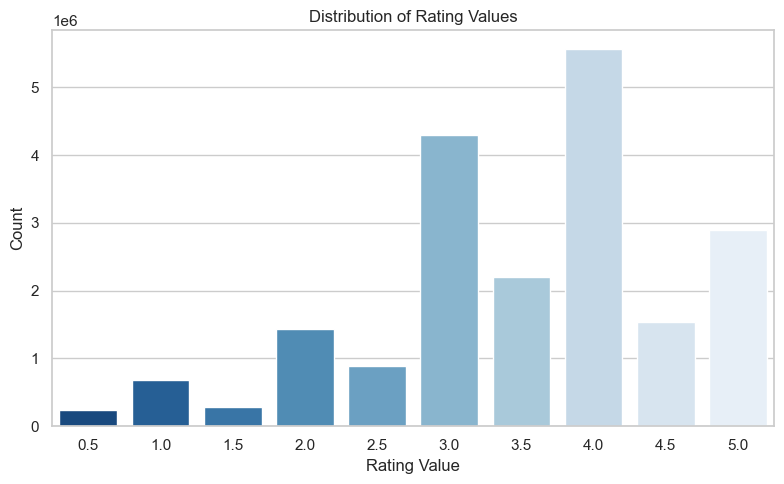

Mean rating: 3.53
Median rating: 3.50


In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings, palette='Blues_r')
plt.title('Distribution of Rating Values')
plt.xlabel('Rating Value')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('ratings_distribution.png', dpi=150)
plt.show()

print(f'Mean rating: {ratings["rating"].mean():.2f}')
print(f'Median rating: {ratings["rating"].median():.2f}')


### Step 5: User Rating Activity
Analyze rating patterns per user (e.g. how many movies users typically rate) and display the distribution on a log scale.


Total unique users: 138493
Average ratings per user: 144.4
Median ratings per user: 68.0


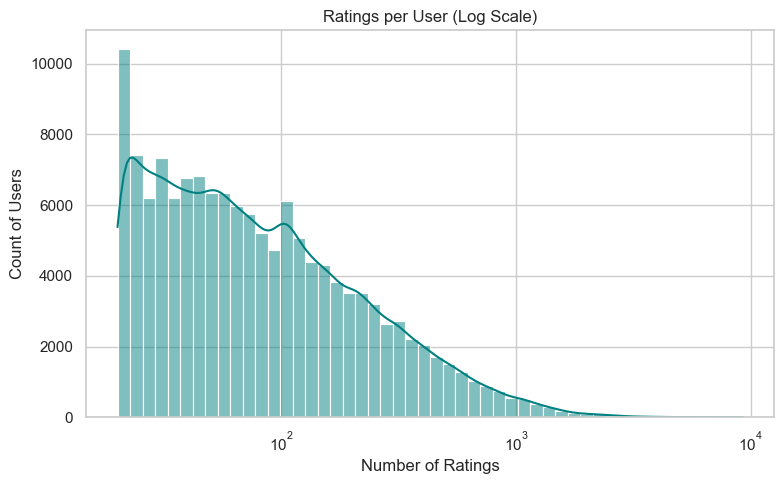

In [5]:
user_counts = ratings['userId'].value_counts()
print(f'Total unique users: {len(user_counts)}')
print(f'Average ratings per user: {user_counts.mean():.1f}')
print(f'Median ratings per user: {user_counts.median():.1f}')

plt.figure(figsize=(8, 5))
sns.histplot(user_counts, bins=50, kde=True, log_scale=True, color='teal')
plt.title('Ratings per User (Log Scale)')
plt.xlabel('Number of Ratings')
plt.ylabel('Count of Users')
plt.tight_layout()
plt.savefig('user_ratings_distribution.png', dpi=150)
plt.show()


### Step 6: Movie Popularity
Analyze rating count per movie to identify blockbusters versus niche movies, and list the top 10 most rated movies.


Total unique rated movies: 26744
Average ratings per movie: 747.8
Median ratings per movie: 18.0


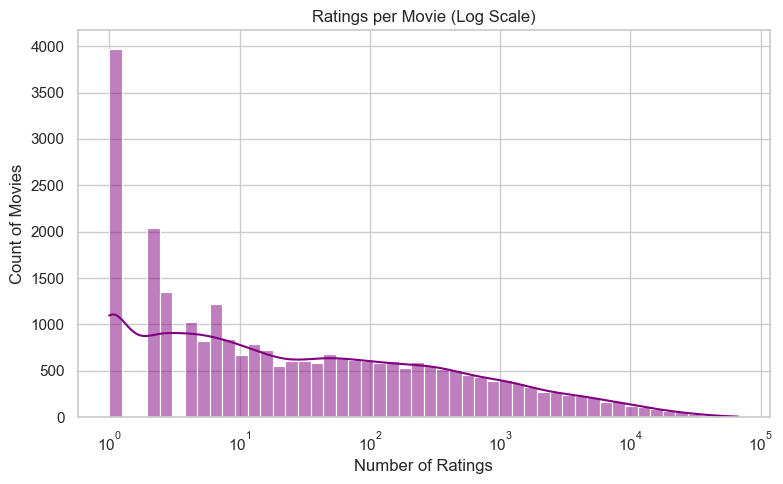

Top 10 Most Rated Movies in the Dataset:
                                       title  rating_count  \
0                        Pulp Fiction (1994)         67310   
1                        Forrest Gump (1994)         66172   
2           Shawshank Redemption, The (1994)         63366   
3           Silence of the Lambs, The (1991)         63299   
4                       Jurassic Park (1993)         59715   
5  Star Wars: Episode IV - A New Hope (1977)         54502   
6                          Braveheart (1995)         53769   
7          Terminator 2: Judgment Day (1991)         52244   
8                         Matrix, The (1999)         51334   
9                    Schindler's List (1993)         50054   

                             genres  
0       Comedy|Crime|Drama|Thriller  
1          Comedy|Drama|Romance|War  
2                       Crime|Drama  
3             Crime|Horror|Thriller  
4  Action|Adventure|Sci-Fi|Thriller  
5           Action|Adventure|Sci-Fi  
6         

In [6]:
movie_counts = ratings['movieId'].value_counts()
print(f'Total unique rated movies: {len(movie_counts)}')
print(f'Average ratings per movie: {movie_counts.mean():.1f}')
print(f'Median ratings per movie: {movie_counts.median():.1f}')

plt.figure(figsize=(8, 5))
sns.histplot(movie_counts, bins=50, kde=True, log_scale=True, color='purple')
plt.title('Ratings per Movie (Log Scale)')
plt.xlabel('Number of Ratings')
plt.ylabel('Count of Movies')
plt.tight_layout()
plt.savefig('movie_ratings_distribution.png', dpi=150)
plt.show()

top_movies = movie_counts.head(10).reset_index()
top_movies.columns = ['movieId', 'rating_count']
top_movies = top_movies.merge(movies, on='movieId')
print('Top 10 Most Rated Movies in the Dataset:')
print(top_movies[['title', 'rating_count', 'genres']])


### Step 7: Downsample the Dataset
To build content-based matrices and collaborative filtering models that can run within seconds and fit in memory, we downsample the dataset.
We select active users who have rated $\ge 1000$ movies, and popular movies that have $\ge 1000$ ratings. This keeps the dataset dense, high-quality, and computationally manageable.


In [7]:
active_users = user_counts[user_counts >= 1000].index
popular_movies = movie_counts[movie_counts >= 1000].index

ratings_sampled = ratings[ratings['userId'].isin(active_users) & ratings['movieId'].isin(popular_movies)]
movies_sampled = movies[movies['movieId'].isin(popular_movies)]

print(f'Sampled Ratings shape: {ratings_sampled.shape}')
print(f'Sampled Movies shape: {movies_sampled.shape}')
print(f'Sampled Unique Users: {ratings_sampled["userId"].nunique()}')
print(f'Sampled Unique Movies: {ratings_sampled["movieId"].nunique()}')


Sampled Ratings shape: (2033580, 4)
Sampled Movies shape: (3159, 3)
Sampled Unique Users: 1894
Sampled Unique Movies: 3159


### Step 8: Save the Sampled Datasets
We save these clean subsets to CSV files so that downstream notebooks can load them directly and run instantly.


In [8]:
ratings_sampled.to_csv('ratings_sampled.csv', index=False)
movies_sampled.to_csv('movies_sampled.csv', index=False)
print('Sampled datasets successfully saved as "ratings_sampled.csv" and "movies_sampled.csv".')


Sampled datasets successfully saved as "ratings_sampled.csv" and "movies_sampled.csv".
